In [9]:
# 아래 두 값을 변경한 뒤, 위에서부터 모든 셀을 실행하세요.
Folder_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\0minimized_csv파일"

Time_range = (2, 3)  # None: 전체 구간

shift_time_to_zero = True  # True: 추출한 첫 시점을 0초로 변경

결과 폴더: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일

[1/9] 01._-0.58V_0.5mm.csv


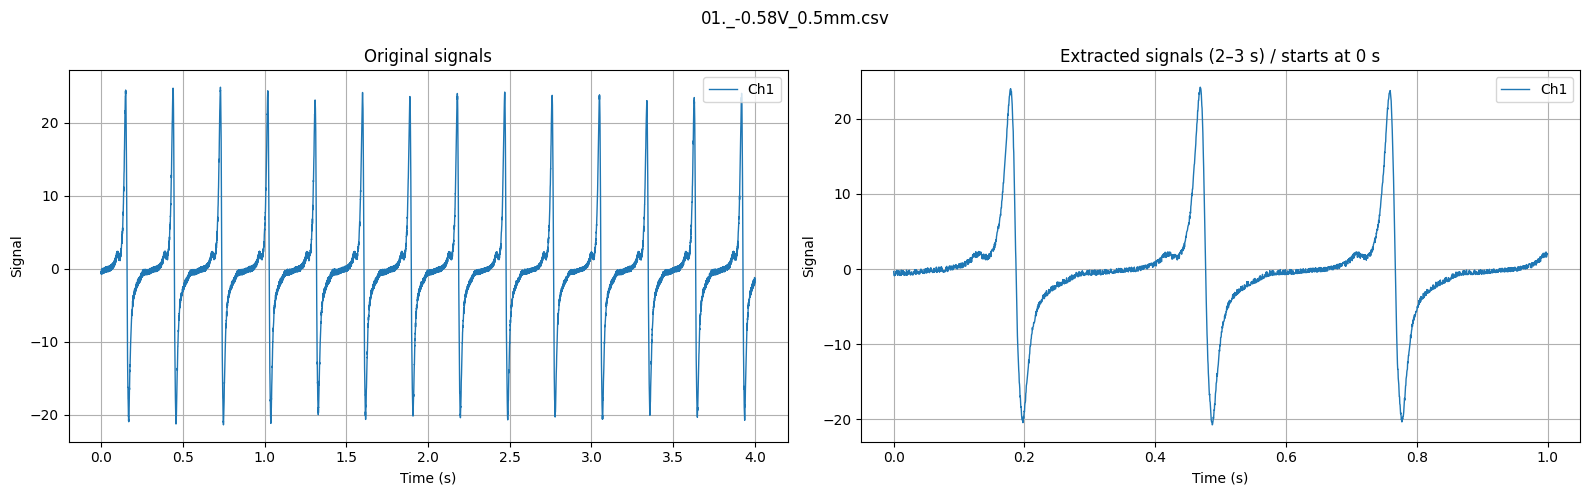

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_01._-0.58V_0.5mm.csv (2,500행)

[2/9] 02._-0.15V_ionizer.csv


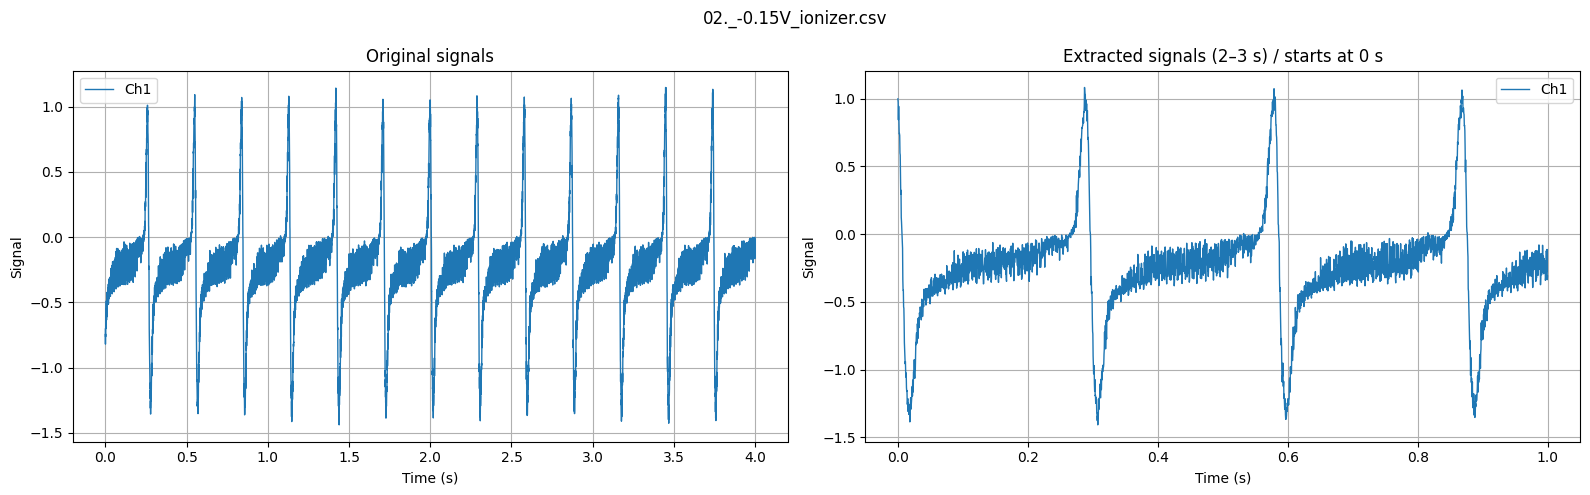

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_02._-0.15V_ionizer.csv (2,500행)

[3/9] 02._-0.18V_ionizer.csv


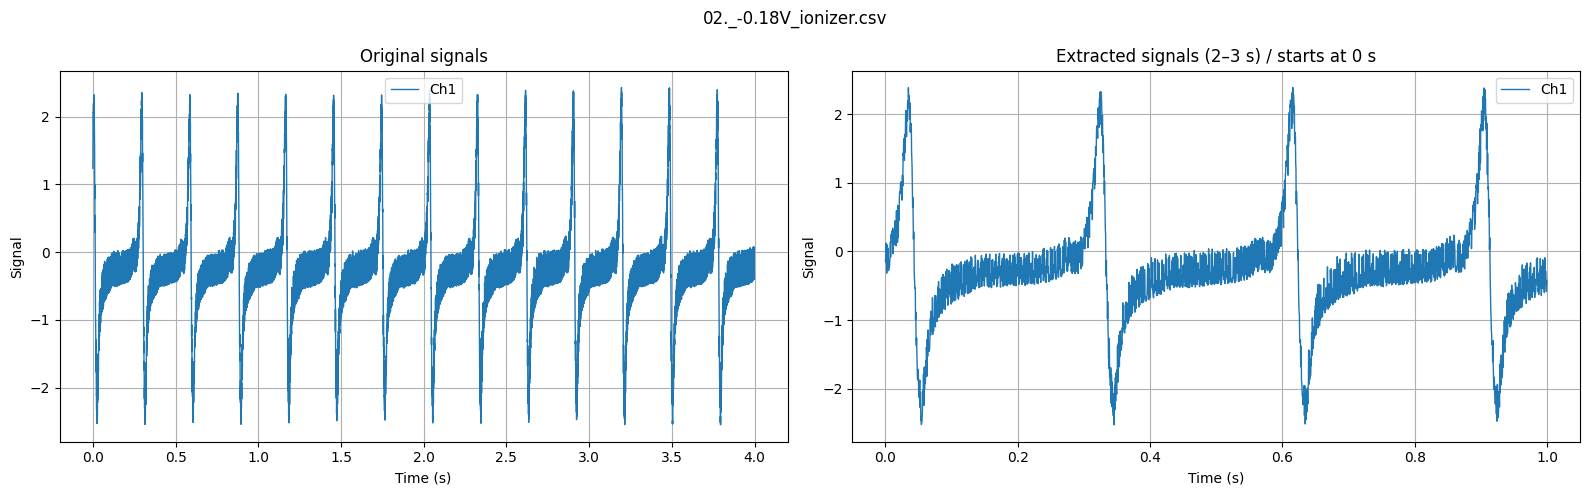

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_02._-0.18V_ionizer.csv (2,500행)

[4/9] 03._-0.47V_ionizer.csv


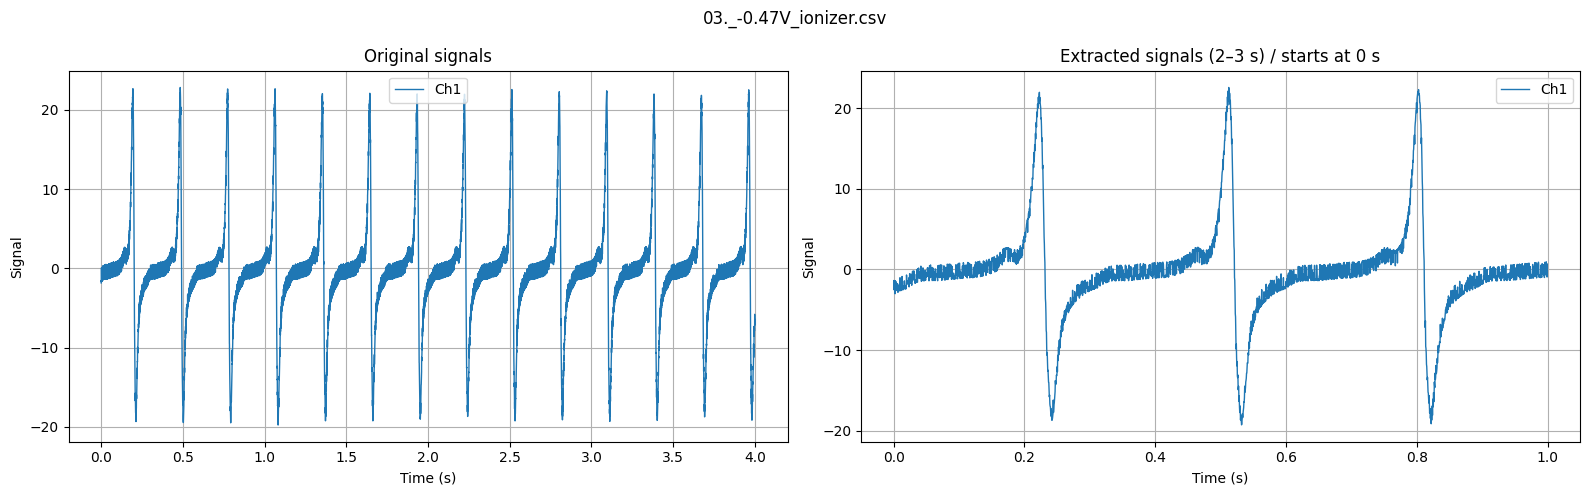

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_03._-0.47V_ionizer.csv (2,500행)

[5/9] 04._-0.33V_ionizer.csv


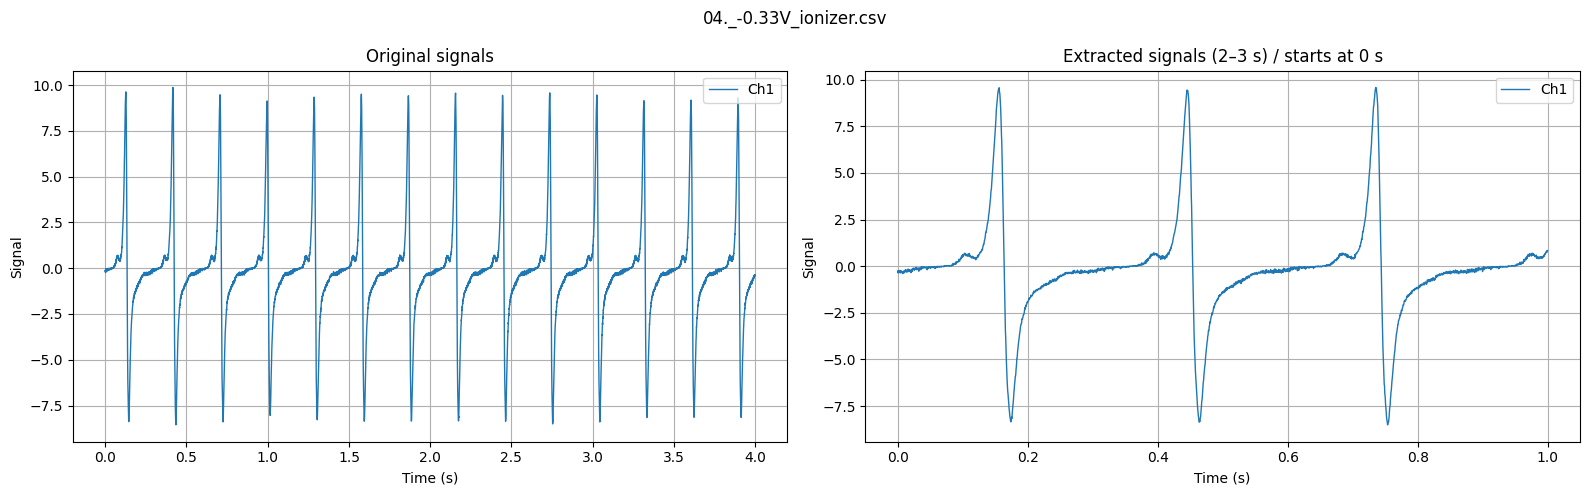

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_04._-0.33V_ionizer.csv (2,500행)

[6/9] 05._-0.27V.csv


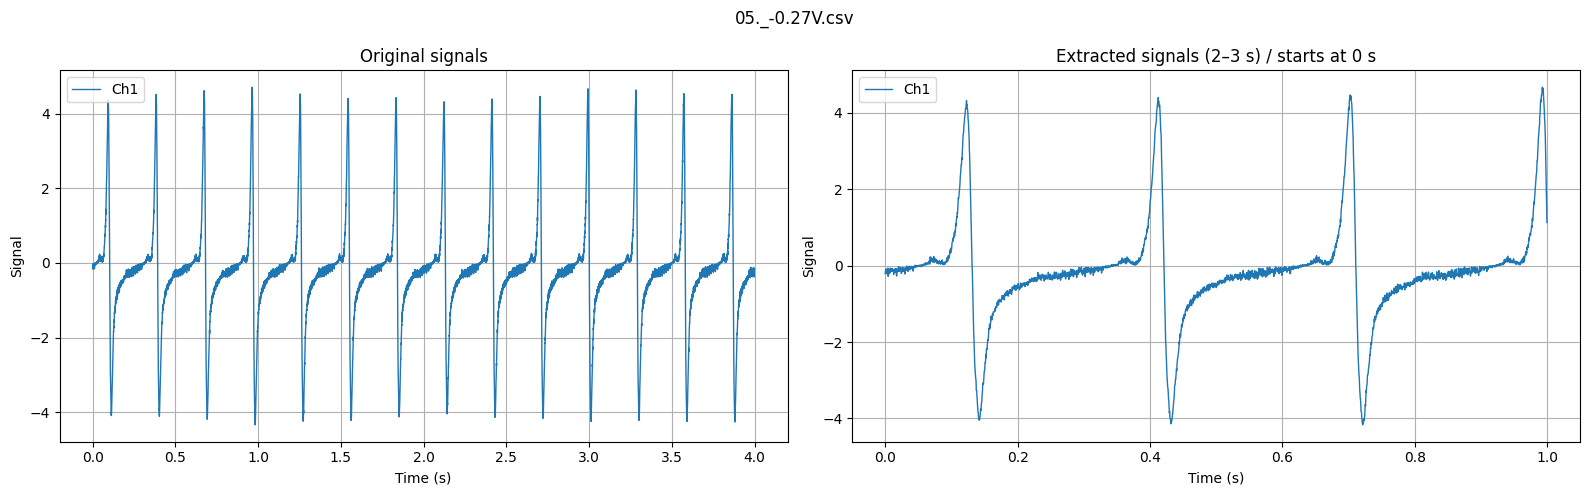

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_05._-0.27V.csv (2,500행)

[7/9] 06._-0.23V.csv


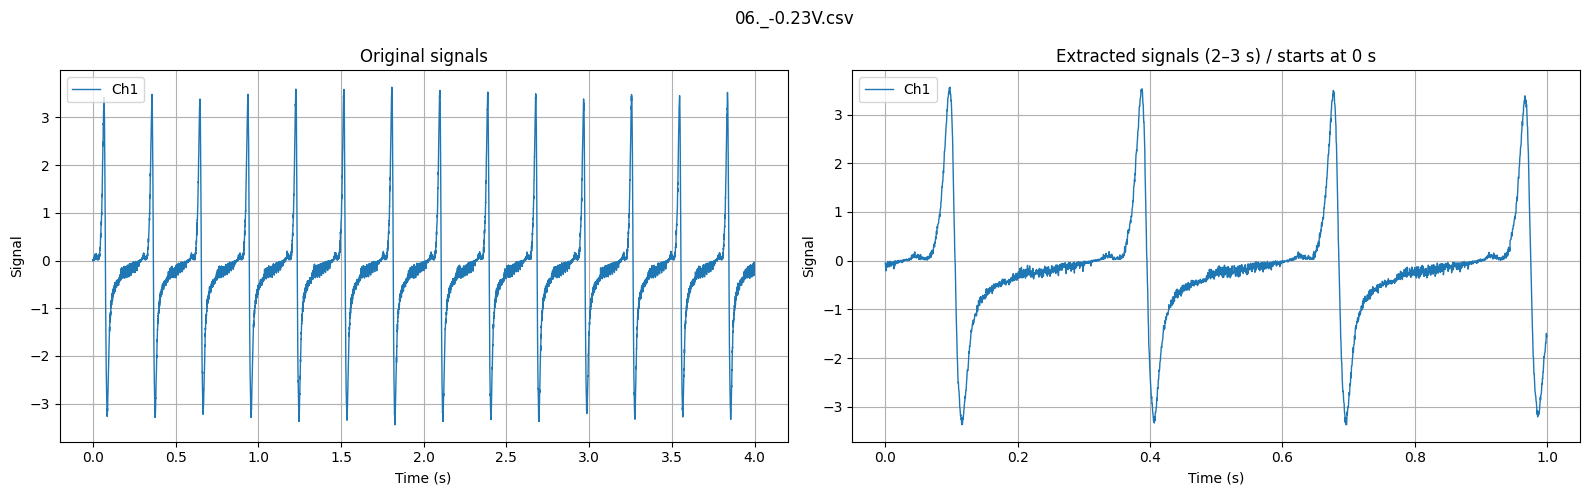

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_06._-0.23V.csv (2,500행)

[8/9] 07._-0.60V_Full_charging.csv


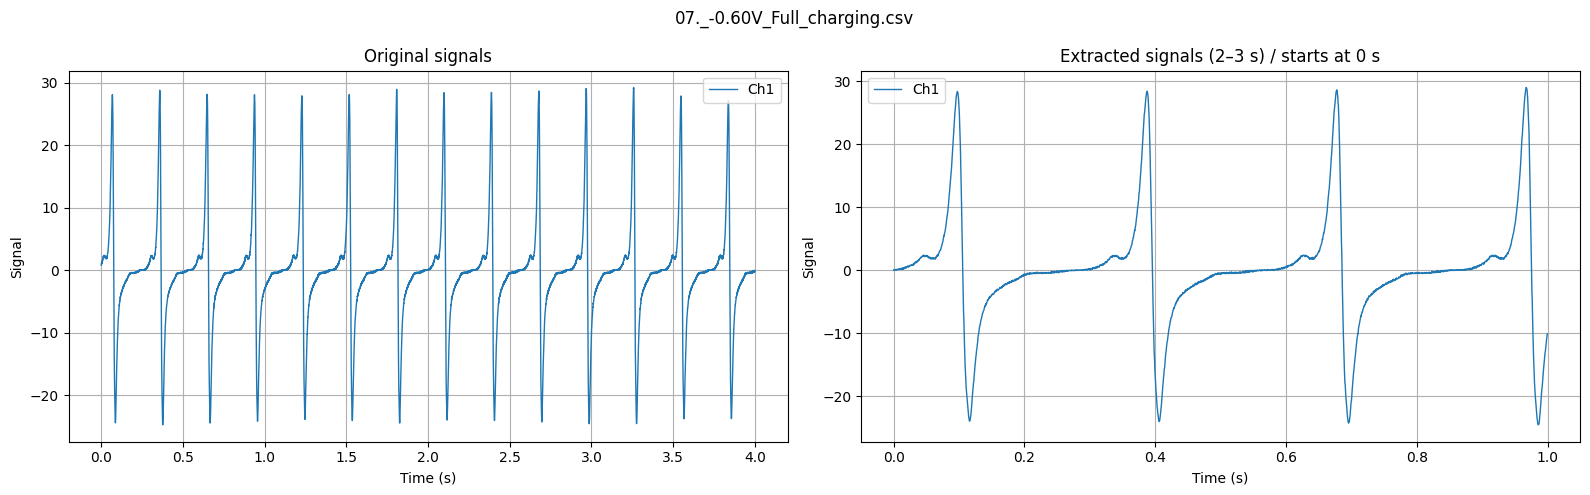

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_07._-0.60V_Full_charging.csv (2,500행)

[9/9] 08._-0.20V_ethanol.csv


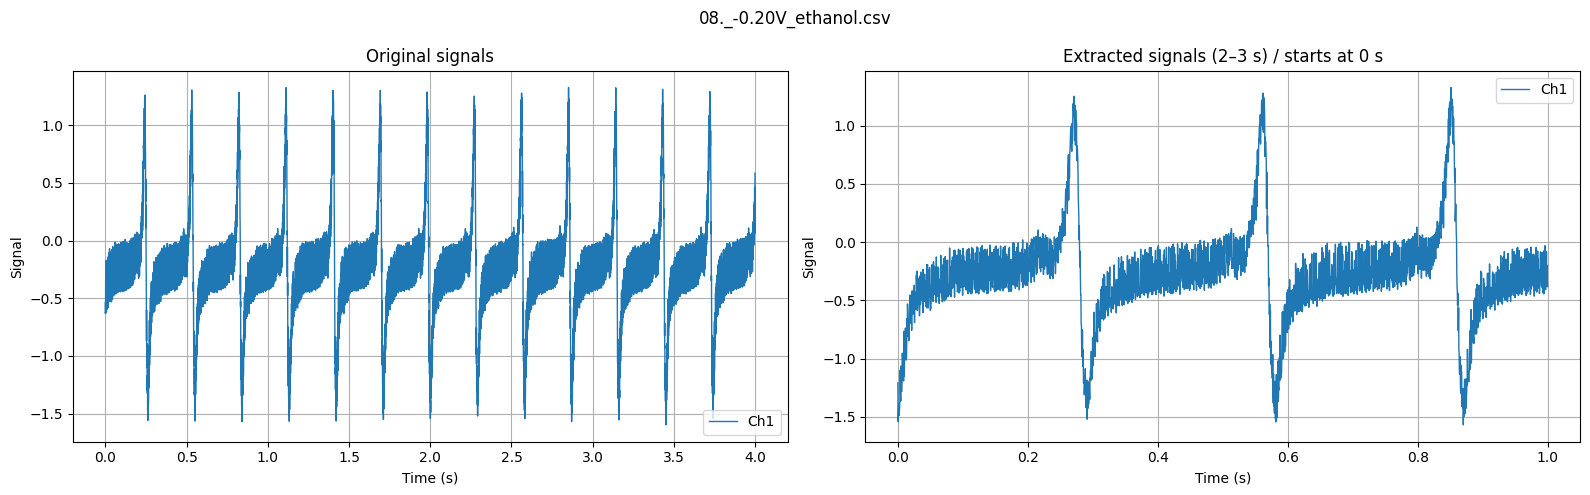

저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260930_이오나이저\Extracted_0minimized_csv파일\Cut_08._-0.20V_ethanol.csv (2,500행)

저장 완료: 9/9개


In [10]:
from pathlib import Path

from itertools import cycle

import matplotlib.pyplot as plt
import pandas as pd


PLOT_COLORS = [
    "#1f77b4",
    "#d62728",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]


def load_multichannel_csv(file_path, *, header=None, skiprows=0, current_scale=None):
    df = pd.read_csv(file_path, header=header, skiprows=skiprows)
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="all")

    if df.shape[1] < 2:
        raise ValueError("At least 2 columns are required: Time + 1 channel.")

    df.columns = ["Time"] + [f"Ch{i}" for i in range(1, df.shape[1])]
    df = df.dropna(subset=["Time"]).reset_index(drop=True)

    if current_scale is not None:
        signal_cols = list(df.columns[1:])
        df.loc[:, signal_cols] = df.loc[:, signal_cols] * float(current_scale)

    return df


def filter_time_range(df, time_range, *, shift_to_zero=False):
    if time_range is None:
        return df.copy()

    if len(time_range) != 2:
        raise ValueError("time_range must be None or a tuple like (start, end).")

    start, end = map(float, time_range)
    filtered = df[(df["Time"] >= start) & (df["Time"] <= end)].copy()

    if filtered.empty:
        raise ValueError(f"No data found in time range {time_range}.")

    filtered.reset_index(drop=True, inplace=True)

    if shift_to_zero:
        filtered.loc[:, "Time"] = filtered["Time"] - float(filtered.loc[0, "Time"])

    return filtered


def create_output_folder(input_folder):
    input_folder = input_folder.resolve()
    base_name = f"Extracted_{input_folder.name}"
    suffix = 0
    while True:
        name = base_name if suffix == 0 else f"{base_name}_{suffix}"
        output_folder = input_folder.parent / name
        try:
            output_folder.mkdir()
            return output_folder
        except FileExistsError:
            suffix += 1


def save_cut_csv(df, file_path):
    df.to_csv(file_path, index=False, header=False, encoding="utf-8-sig", mode="x")


def plot_original_and_cut(df, df_filtered, *, filename, time_range, shifted):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    cut_title = "Extracted signals"
    if time_range is not None:
        cut_title += f" ({time_range[0]:g}–{time_range[1]:g} s)"
        if shifted:
            cut_title += " / starts at 0 s"

    for ax, data, title in zip(
        axes,
        (df, df_filtered),
        ("Original signals", cut_title),
    ):
        for channel, color in zip(data.columns[1:], cycle(PLOT_COLORS)):
            ax.plot(data["Time"], data[channel], label=channel, color=color, linewidth=1.0)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.set_title(title)
        ax.grid(True)
        ax.legend()

    fig.suptitle(filename)
    fig.tight_layout()
    try:
        plt.show()
    finally:
        plt.close(fig)# 폴더 및 시간 범위를 확인합니다.
input_folder = Path(Folder_path).expanduser()
if not input_folder.is_dir():
    raise NotADirectoryError(f"폴더를 찾을 수 없습니다: {input_folder}")

time_range = None
if Time_range is not None:
    if len(Time_range) != 2:
        raise ValueError("Time_range는 (시작 초, 종료 초) 또는 None으로 설정하세요.")
    start, end = map(float, Time_range)
    if not (float("-inf") < start <= end < float("inf")):
        raise ValueError("시작과 종료는 유한한 숫자이며, 시작 <= 종료여야 합니다.")
    time_range = (start, end)

# 하위 폴더와 기존 Cut_ 결과는 제외합니다.
csv_files = sorted(
    (
        path for path in input_folder.iterdir()
        if path.is_file()
        and path.suffix.lower() == ".csv"
        and not path.name.lower().startswith("cut_")
    ),
    key=lambda path: path.name.lower(),
)
if not csv_files:
    raise FileNotFoundError(f"처리할 원본 CSV 파일이 없습니다: {input_folder}")

# 실행할 때마다 새 결과 폴더를 만듭니다. 같은 이름이 있으면 번호를 붙입니다.
output_folder = create_output_folder(input_folder)
print(f"결과 폴더: {output_folder}")

saved_count = 0
for index, csv_path in enumerate(csv_files, start=1):
    print(f"\n[{index}/{len(csv_files)}] {csv_path.name}")
    try:
        df = load_multichannel_csv(csv_path, header=None)
        df_filtered = filter_time_range(
            df, time_range, shift_to_zero=shift_time_to_zero
        )

        # 왼쪽: 원본 전체 구간 / 오른쪽: Time_range로 추출한 구간
        plot_original_and_cut(
            df,
            df_filtered,
            filename=csv_path.name,
            time_range=time_range,
            shifted=shift_time_to_zero,
        )

        output_path = output_folder / f"Cut_{csv_path.name}"
        save_cut_csv(df_filtered, output_path)
        saved_count += 1
        print(f"저장 완료: {output_path} ({len(df_filtered):,d}행)")
    except Exception as exc:
        print(f"처리 실패: {type(exc).__name__}: {exc}")

print(f"\n저장 완료: {saved_count}/{len(csv_files)}개")